In [ ]:
import kagglehub

# Descargo version más reciente
path = kagglehub.dataset_download("carlosborrajo/madrid-bike-sharing-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\dpuer\.cache\kagglehub\datasets\carlosborrajo\madrid-bike-sharing-dataset\versions\1


In [2]:
# 1. LIBRERÍAS BÁSICAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Modelos
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Configuraciones estéticas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [4]:

path = r"C:\Users\dpuer\.cache\kagglehub\datasets\carlosborrajo\madrid-bike-sharing-dataset\versions\1"
files = os.listdir(path)
print(files)

['bicimad_trips.csv']


In [6]:
# CARGAR LOS DATOS
path = r"C:\Users\dpuer\.cache\kagglehub\datasets\carlosborrajo\madrid-bike-sharing-dataset\versions\1"

df = pd.read_csv(os.path.join(path, "bicimad_trips.csv"), parse_dates=['fecha', 'unlock_date', 'lock_date'])

# Vista rápida
print(df.shape)
print(df.dtypes)
df.head()


(4144134, 19)
Unnamed: 0                      int64
fecha                  datetime64[ns]
idBike                        float64
fleet                         float64
trip_minutes                  float64
geolocation_unlock             object
address_unlock                 object
unlock_date            datetime64[ns]
locktype                       object
unlocktype                     object
geolocation_lock               object
address_lock                   object
lock_date              datetime64[ns]
station_unlock                 object
dock_unlock                   float64
unlock_station_name            object
station_lock                  float64
dock_lock                     float64
lock_station_name              object
dtype: object


,Unnamed: 0,fecha,idBike,fleet,trip_minutes,geolocation_unlock,address_unlock,unlock_date,locktype,unlocktype,geolocation_lock,address_lock,lock_date,station_unlock,dock_unlock,unlock_station_name,station_lock,dock_lock,lock_station_name
0,0,2022-01-01,1718.0,1.0,16.28,"{'type': 'Point', 'coordinates': [-3.6714166, ...",NaN,2022-01-01 00:02:20,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688398, 4...",NaN,2022-01-01 00:18:37,200.0,3.0,Avenida de los Toreros,64.0,4.0,Plaza de la Independencia
1,1,2022-01-01,7340.0,1.0,7.10,"{'type': 'Point', 'coordinates': [-3.6894193, ...",NaN,2022-01-01 00:07:53,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6993465, ...",NaN,2022-01-01 00:14:59,69.0,5.0,Antonio Maura,169.0,17.0,Manuel Silvela
2,2,2022-01-01,3861.0,1.0,0.48,"{'type': 'Point', 'coordinates': [-3.688822, 4...",NaN,2022-01-01 00:09:21,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688822, 4...",NaN,2022-01-01 00:09:50,73.0,21.0,Puerta del Ángel Caído,73.0,21.0,Puerta del Ángel Caído
3,3,2022-01-01,7657.0,1.0,6.62,"{'type': 'Point', 'coordinates': [-3.6653055, ...",NaN,2022-01-01 00:09:52,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6657777, ...",NaN,2022-01-01 00:16:29,192.0,22.0,Marqués de Zafra,190.0,17.0,Parque Roma
4,4,2022-01-01,6653.0,1.0,8.07,"{'type': 'Point', 'coordinates': [-3.6983055, ...",NaN,2022-01-01 00:09:57,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.7025024, ...",NaN,2022-01-01 00:18:01,183.0,3.0,Jaime el Conquistador,47.0,24.0,Jesús y María


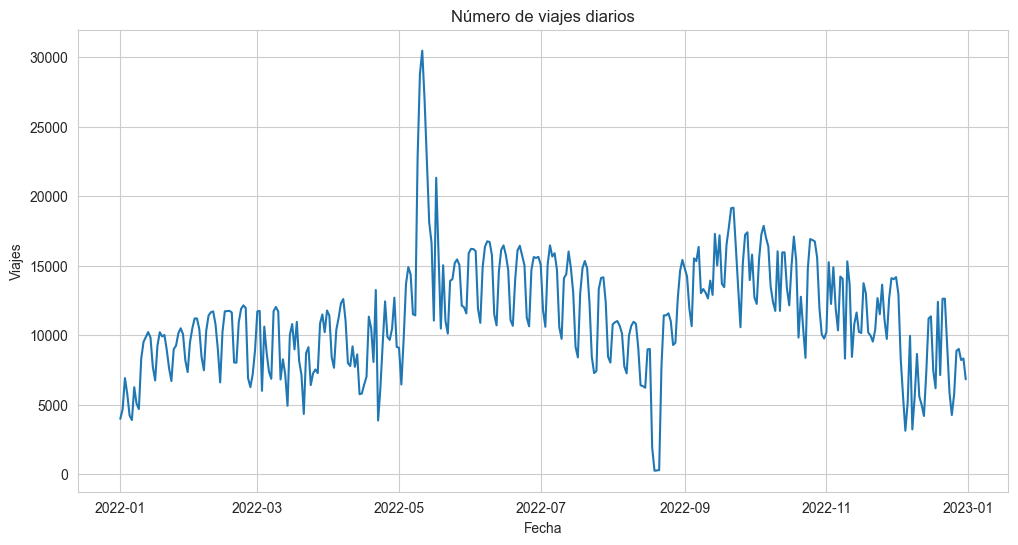

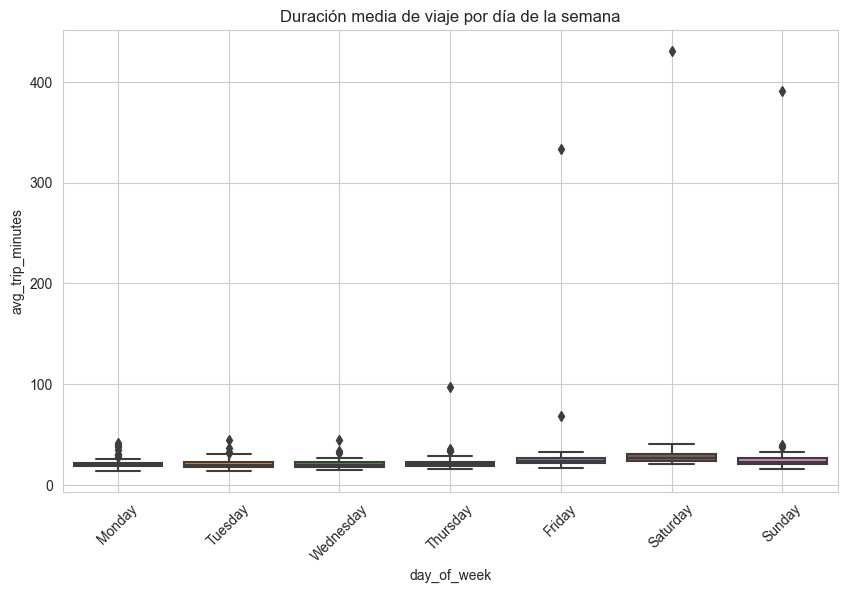

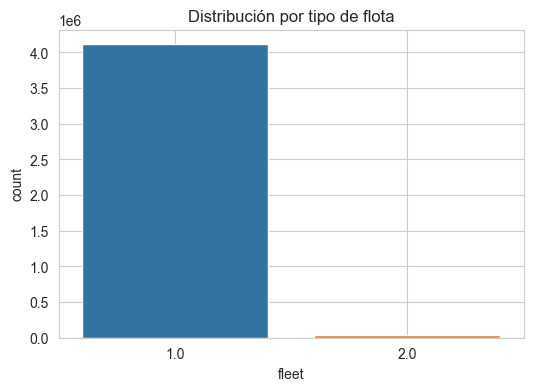

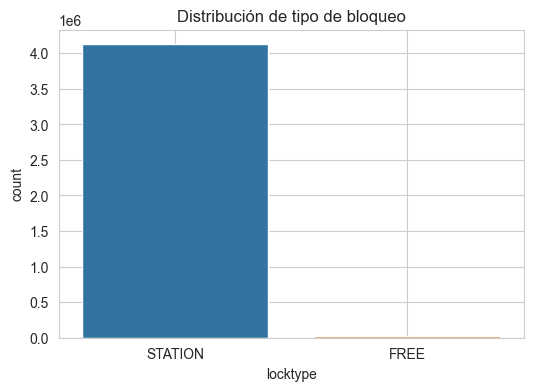

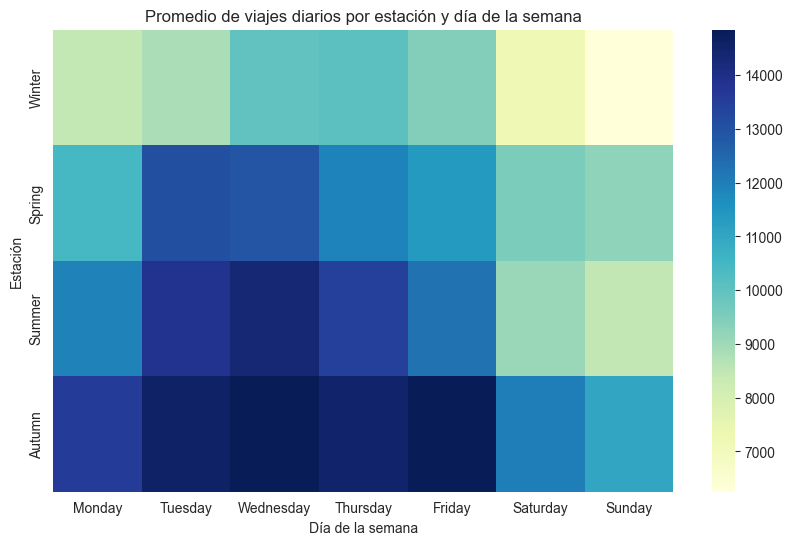

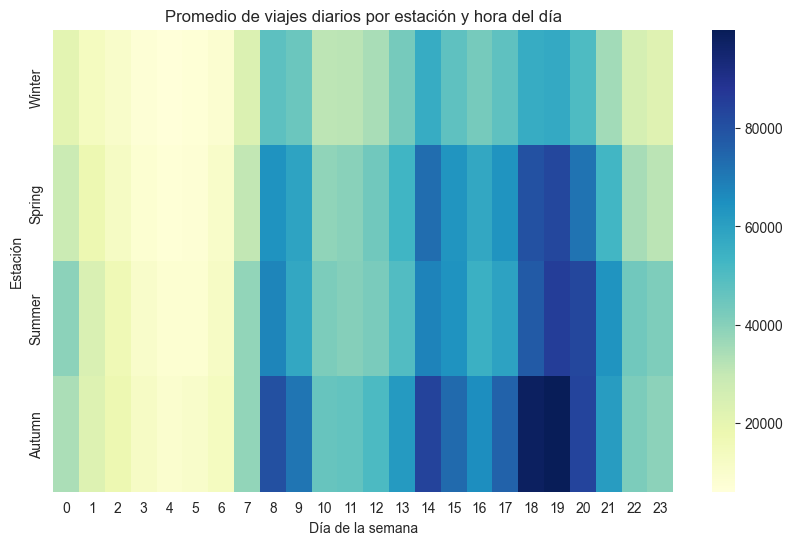

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['hour'] = df['unlock_date'].dt.hour
df['hour'] = df['hour'].astype(int)
# Número de viajes por día
df_daily = df.groupby('fecha').agg(
    trips_count=('idBike', 'count'),
    avg_trip_minutes=('trip_minutes', 'mean')
).reset_index()

# Añadir día de la semana
df_daily['day_of_week'] = df_daily['fecha'].dt.day_name()
# Añadir hora de desbloqueo

# Añadir estación del año
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_daily['season'] = df_daily['fecha'].apply(get_season)

# Gráfico de número de viajes diarios
plt.figure(figsize=(12, 6))
plt.plot(df_daily['fecha'], df_daily['trips_count'])
plt.title('Número de viajes diarios')
plt.xlabel('Fecha')
plt.ylabel('Viajes')
plt.grid(True)
plt.show()

# Boxplot de duración media de viaje por día de la semana
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='avg_trip_minutes', data=df_daily, order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Duración media de viaje por día de la semana')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Análisis flotas
plt.figure(figsize=(6, 4))
sns.countplot(x='fleet', data=df)
plt.title('Distribución por tipo de flota')
plt.grid(True)
plt.show()

# Tipo de anclaje
plt.figure(figsize=(6, 4))
sns.countplot(x='locktype', data=df)
plt.title('Distribución de tipo de bloqueo')
plt.grid(True)
plt.show()

# Heatmap viajes por estación y día de la semana
pivot_table = df_daily.pivot_table(index='season', columns='day_of_week', values='trips_count', aggfunc='mean')

# Aseguro orden correcto
pivot_table = pivot_table.reindex(index=['Winter', 'Spring', 'Summer', 'Autumn'])
pivot_table = pivot_table[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=False, fmt=".0f", cmap="YlGnBu")
plt.title('Promedio de viajes diarios por estación y día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Estación')
plt.show()

df['season'] = df['fecha'].apply(get_season)

df_hour = df.groupby(['hour', 'season']).agg(
    trips_count=('idBike', 'count'),
    avg_trip_minutes=('trip_minutes', 'mean')
).reset_index()

pivot_table = df_hour.pivot_table(index='season', columns='hour', values='trips_count', aggfunc='mean')


# Aseguro orden correcto
pivot_table = pivot_table.reindex(index=['Winter', 'Spring', 'Summer', 'Autumn'])


plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=False, fmt=".0f", cmap="YlGnBu")
plt.title('Promedio de viajes diarios por estación y hora del día')
plt.xlabel('Día de la semana')
plt.ylabel('Estación')
plt.show()

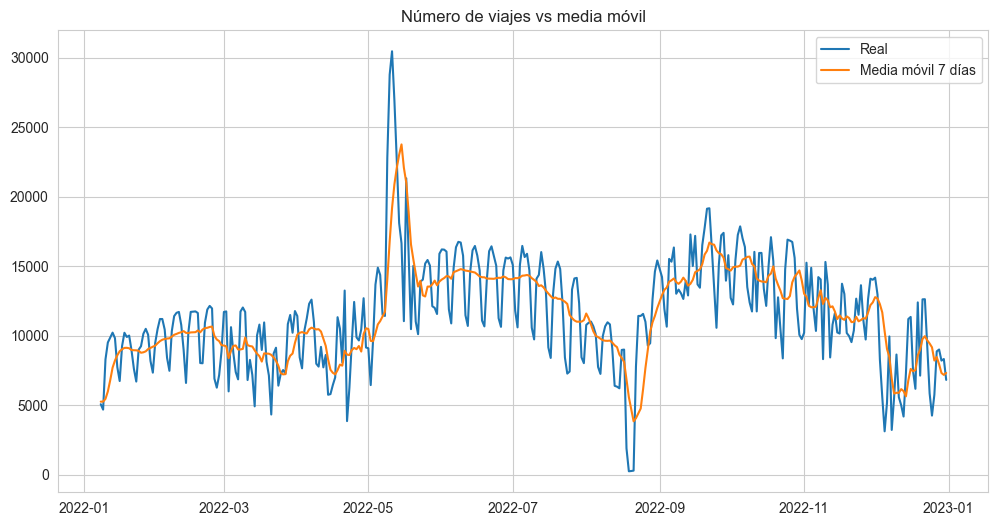

In [ ]:
# Genero variables adicionales
df_daily['is_weekend'] = df_daily['day_of_week'].isin(['Saturday', 'Sunday'])
df_daily['month'] = df_daily['fecha'].dt.month
df_daily['year'] = df_daily['fecha'].dt.year
df_daily['day_of_year'] = df_daily['fecha'].dt.dayofyear

# Lag features
df_daily['lag_1'] = df_daily['trips_count'].shift(1)
df_daily['lag_7'] = df_daily['trips_count'].shift(7)
df_daily['rolling_mean_7'] = df_daily['trips_count'].rolling(window=7).mean()

# Drop NA generados por lagging
df_daily = df_daily.dropna()

# Visualización de media móvil
plt.plot(df_daily['fecha'], df_daily['trips_count'], label='Real')
plt.plot(df_daily['fecha'], df_daily['rolling_mean_7'], label='Media móvil 7 días')
plt.legend()
plt.title('Número de viajes vs media móvil')
plt.show()


In [9]:
df_daily.columns

Index(['fecha', 'trips_count', 'avg_trip_minutes', 'day_of_week', 'season',
       'is_weekend', 'month', 'year', 'day_of_year', 'lag_1', 'lag_7',
       'rolling_mean_7'],
      dtype='object')

In [ ]:
# Train/test split basado en fecha
split_date = '2022-11-01'

train = df_daily[df_daily['fecha'] < split_date]
test = df_daily[df_daily['fecha'] >= split_date]

print(train.shape, test.shape)


(297, 12) (61, 12)


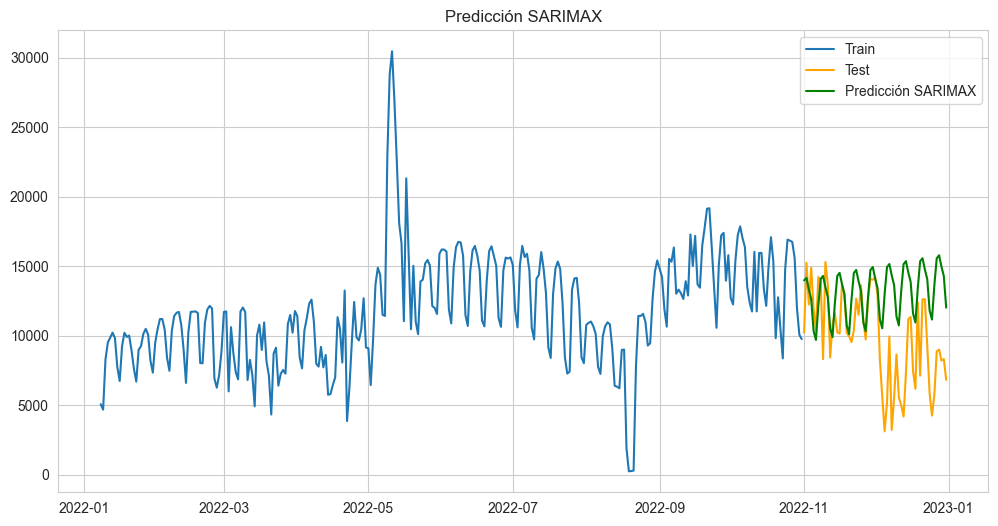

MAE SARIMAX: 3643.83
RMSE SARIMAX: 4763.77


In [11]:
# SARIMAX básico
sarimax_model = SARIMAX(train['trips_count'], order=(1,1,1), seasonal_order=(1,1,1,7))
sarimax_result = sarimax_model.fit(disp=False)

# Predicciones
sarimax_forecast = sarimax_result.predict(start=test.index[0], end=test.index[-1])

# Gráfico comparación
plt.plot(train['fecha'], train['trips_count'], label='Train')
plt.plot(test['fecha'], test['trips_count'], label='Test', color='orange')
plt.plot(test['fecha'], sarimax_forecast, label='Predicción SARIMAX', color='green')
plt.legend()
plt.title('Predicción SARIMAX')
plt.show()

# Evaluación
mae_sarimax = mean_absolute_error(test['trips_count'], sarimax_forecast)
rmse_sarimax = mean_squared_error(test['trips_count'], sarimax_forecast, squared=False)
print(f'MAE SARIMAX: {mae_sarimax:.2f}')
print(f'RMSE SARIMAX: {rmse_sarimax:.2f}')


In [ ]:
# Creo las nuevas características de lag y rolling mean
df_daily['lag_1'] = df_daily['trips_count'].shift(1)  # Lag 1
df_daily['lag_7'] = df_daily['trips_count'].shift(7)  # Lag 7
df_daily['rolling_mean_7'] = df_daily['trips_count'].rolling(window=7).mean()  # Rolling Mean de 7 días

# Lleno los valores nulos creados por el shift y rolling mean
df_daily = df_daily.fillna(method='bfill')

# Añado la columna 'is_weekend' (fin de semana = True, de lo contrario = False)
df_daily['is_weekend'] = df_daily['day_of_week'].isin([5, 6]).astype(int)  # 5 = Sábado, 6 = Domingo

# Convierto 'day_of_week' de tipo texto a números (0 = Lunes, 1 = Martes, ..., 6 = Domingo)
day_of_week_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df_daily['day_of_week'] = df_daily['day_of_week'].map(day_of_week_map)

# Convierto 'season' a números (1 = Invierno, 2 = Primavera, 3 = Verano, 4 = Otoño)
season_map = {'Winter': 1, 'Spring': 2, 'Summer': 3, 'Autumn': 4}  # Si se tienen otras definiciones, se debe ajustar  este mapeo
df_daily['season'] = df_daily['season'].map(season_map)


In [13]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 358 entries, 7 to 364
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             358 non-null    datetime64[ns]
 1   trips_count       358 non-null    int64         
 2   avg_trip_minutes  358 non-null    float64       
 3   day_of_week       358 non-null    int64         
 4   season            358 non-null    int64         
 5   is_weekend        358 non-null    int32         
 6   month             358 non-null    int64         
 7   year              358 non-null    int64         
 8   day_of_year       358 non-null    int64         
 9   lag_1             358 non-null    float64       
 10  lag_7             358 non-null    float64       
 11  rolling_mean_7    358 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int32(1), int64(6)
memory usage: 35.0 KB


In [14]:
# Train/test split basado en fecha
split_date = '2022-11-01'  # Cambio adaptado a los datos de 2022

train = df_daily[df_daily['fecha'] < split_date]
test = df_daily[df_daily['fecha'] >= split_date]

print(train.shape, test.shape)

(297, 12) (61, 12)


MAE XGBoost: 1898.44
RMSE XGBoost: 2433.58


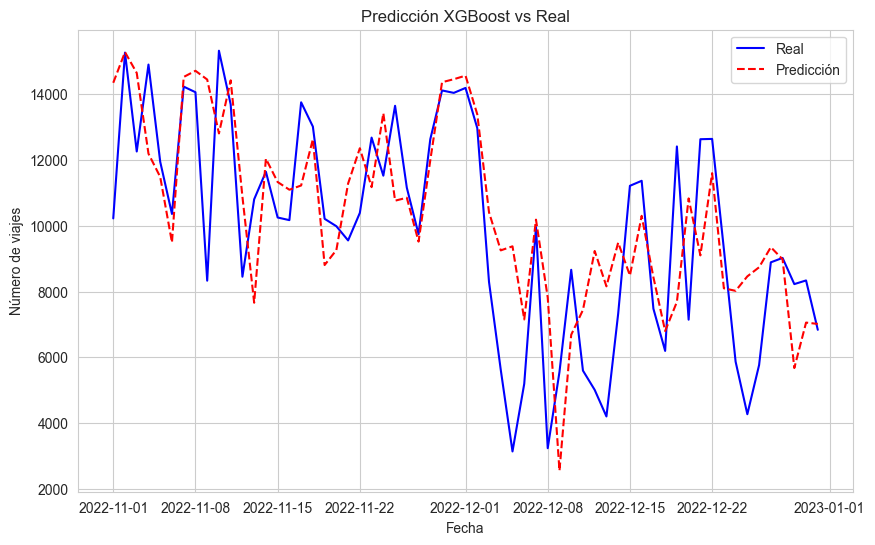

In [ ]:
# X y y para entrenamiento (uso varias características, incluidas lag, rolling mean, y season)
X_train = train[['day_of_week', 'season', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']]
y_train = train['trips_count']
X_test = test[['day_of_week', 'season', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']]
y_test = test['trips_count']

# Crear y entrenar el modelo XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.01, max_depth=10)
xgb_model.fit(X_train, y_train)

# Predicciones sobre el conjunto de test
y_pred = xgb_model.predict(X_test)

# Evaluación del modelo
mae_xgb = mean_absolute_error(y_test, y_pred)
rmse_xgb = mean_squared_error(y_test, y_pred, squared=False)
print(f'MAE XGBoost: {mae_xgb:.2f}')
print(f'RMSE XGBoost: {rmse_xgb:.2f}')

# Gráfico de las predicciones
plt.figure(figsize=(10,6))
plt.plot(test['fecha'], y_test, label='Real', color='blue')
plt.plot(test['fecha'], y_pred, label='Predicción', color='red', linestyle='--')
plt.title('Predicción XGBoost vs Real')
plt.xlabel('Fecha')
plt.ylabel('Número de viajes')
plt.legend()
plt.show()


In [16]:
print(f'''
Resumen de modelos:
---------------------
SARIMAX -> MAE: {mae_sarimax:.2f} - RMSE: {rmse_sarimax:.2f}
XGBOOST -> MAE: {mae_xgb:.2f} - RMSE: {rmse_xgb:.2f}

Conclusiones:
Comparación entre SARIMAX y XGBoost:

El modelo SARIMAX presenta un MAE de 3643.83 y un RMSE de 4763.77, lo que indica que el modelo tiene una mayor desviación media y un error cuadrático medio más alto. Esto sugiere que el modelo SARIMAX tiene un rendimiento inferior en cuanto a la precisión de las predicciones.

El modelo XGBoost, por otro lado, tiene un MAE de 1898.44 y un RMSE de 2433.58, lo que refleja un error significativamente menor en comparación con SARIMAX. El modelo XGBoost ofrece mejores resultados en términos de precisión y error, lo que implica una mayor capacidad para capturar patrones en los datos y hacer predicciones más exactas.

Interpretación de los errores:

MAE (Mean Absolute Error): XGBoost muestra una menor MAE, lo que implica que la diferencia promedio entre las predicciones y los valores reales es más baja, destacando su mejor capacidad para predecir con exactitud.

RMSE (Root Mean Squared Error): El RMSE de XGBoost también es considerablemente menor que el de SARIMAX. Esto resalta que el modelo XGBoost es mejor en la minimización de los errores más grandes y tiene un rendimiento más equilibrado.

Impacto de la elección del modelo:

Dado que XGBoost tiene tanto un MAE como un RMSE más bajos, es evidente que este modelo ofrece un rendimiento superior para las predicciones de número de viajes en comparación con SARIMAX. Esto puede atribuirse a la flexibilidad de XGBoost en capturar relaciones no lineales y su capacidad para ajustarse a datos con características complejas.

El modelo SARIMAX, aunque es robusto para series temporales, parece ser menos adecuado para este conjunto de datos, posiblemente debido a la complejidad de los patrones y factores como los efectos estacionales y las influencias del día de la semana y el fin de semana, que podrían ser mejor modelados por métodos de aprendizaje automático como XGBoost.

Recomendaciones:

Para tareas de predicción de series temporales con características no lineales, como las influencias de días de la semana, estaciones o efectos de fin de semana, XGBoost parece ser una opción más eficaz.

Aunque SARIMAX es un modelo clásico para series temporales, es posible que no capture adecuadamente las interacciones más complejas de las variables de entrada como lo hace XGBoost.

En resumen, XGBoost supera significativamente a SARIMAX en este caso específico, ofreciendo una mayor precisión en las predicciones y un rendimiento más confiable.
''')



Resumen de modelos:
---------------------
SARIMAX -> MAE: 3643.83 - RMSE: 4763.77
XGBOOST -> MAE: 1898.44 - RMSE: 2433.58

Conclusiones:
Comparación entre SARIMAX y XGBoost:

El modelo SARIMAX presenta un MAE de 3643.83 y un RMSE de 4763.77, lo que indica que el modelo tiene una mayor desviación media y un error cuadrático medio más alto. Esto sugiere que el modelo SARIMAX tiene un rendimiento inferior en cuanto a la precisión de las predicciones.

El modelo XGBoost, por otro lado, tiene un MAE de 1898.44 y un RMSE de 2433.58, lo que refleja un error significativamente menor en comparación con SARIMAX. El modelo XGBoost ofrece mejores resultados en términos de precisión y error, lo que implica una mayor capacidad para capturar patrones en los datos y hacer predicciones más exactas.

Interpretación de los errores:

MAE (Mean Absolute Error): XGBoost muestra una menor MAE, lo que implica que la diferencia promedio entre las predicciones y los valores reales es más baja, destacando su me

In [ ]:
# Guardo el modelo
import joblib
joblib.dump(xgb_model, 'xgb_trips_model.pkl')

['xgb_trips_model.pkl']